In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [ ]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [14]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [15]:
df.dropna(inplace=True)

In [17]:
df.shape

(7032, 21)

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
df.drop("customerID", axis=1, inplace=True)

In [20]:
df.shape

(7032, 20)

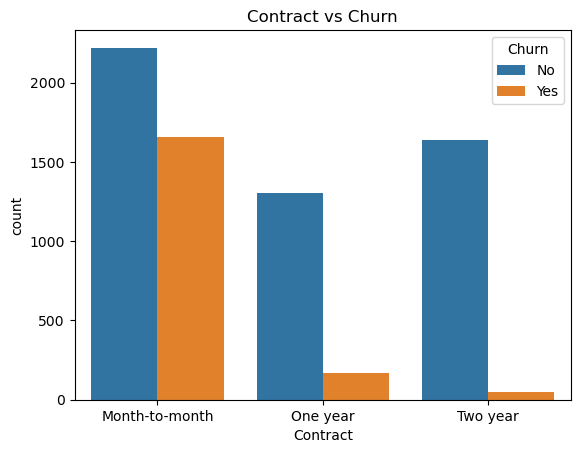

In [21]:
#Does Contract Type affect Customer Churn?
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract vs Churn")
plt.show()

In [ ]:
# #Business Insight:
# Customers with Month-to-Month contracts are much more likely to leave the company compared to customers with one-year or two-year contracts.

    
# #Business Recommendation:
# The company should encourage Month-to-Month customers to switch to longer-term contracts by offering discounts or loyalty rewards.


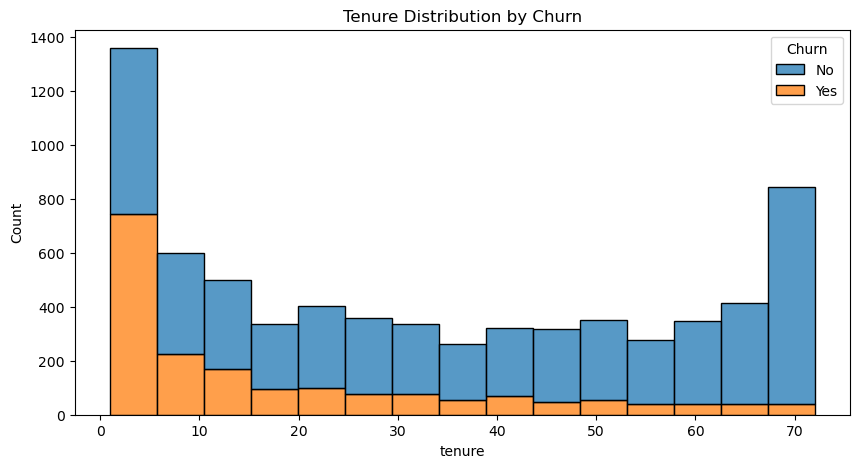

In [24]:
#Does Tenure affect Customer Churn?
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    multiple="stack"
)

plt.title("Tenure Distribution by Churn")
plt.show()

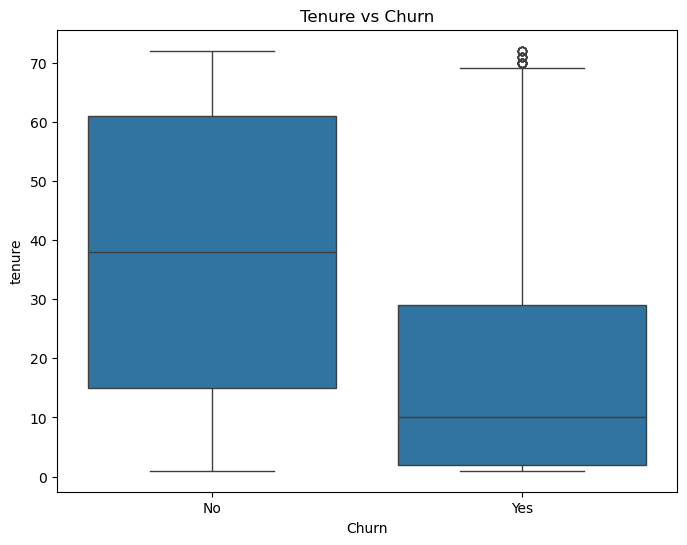

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

In [ ]:
#Business Insight:
Customers who have recently joined the company are more likely to churn, while long-term customers tend to stay loyal.

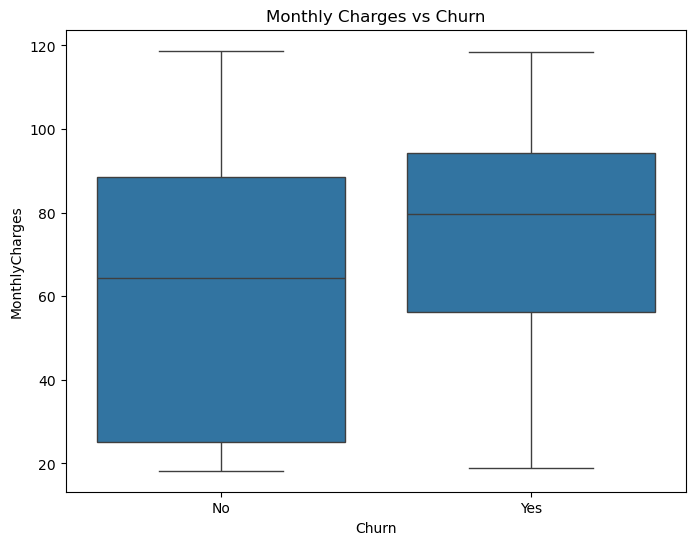

In [27]:
#Do Monthly Charges affect customer churn?
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

In [ ]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


In [ ]:
# #Business Insight:
# Customers with higher monthly charges are more likely to churn than customers with lower monthly charges


# #Business Recommendation
# The company should provide discounts, personalized plans, or loyalty offers to customers with high monthly charges to reduce churn.


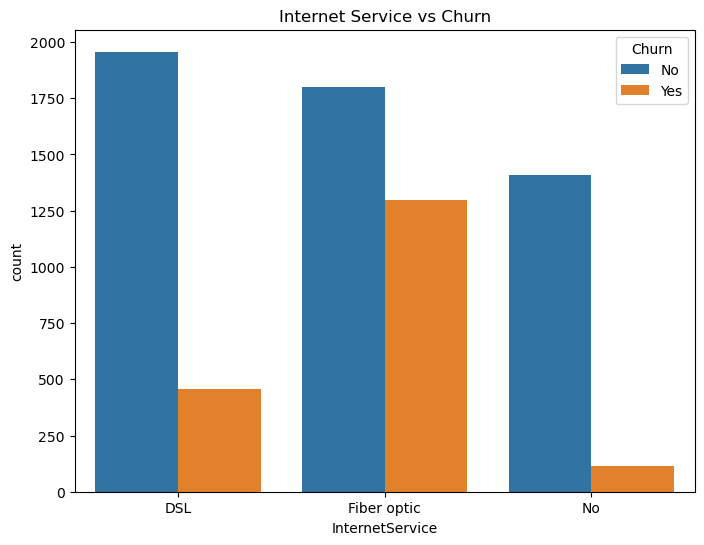

In [34]:
#Does Internet Service affect Customer Churn?
plt.figure(figsize=(8,6))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

In [35]:
#crosstab(normalize='index')
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [ ]:
# #Business Insight
# Customers using Fiber Optic Internet are significantly more likely to churn than customers using DSL or no internet service.
    
# #Business Recommendation
# The company should investigate the Fiber Optic service by reviewing pricing, service quality, and customer complaints.
# Special retention offers should target Fiber Optic customers.


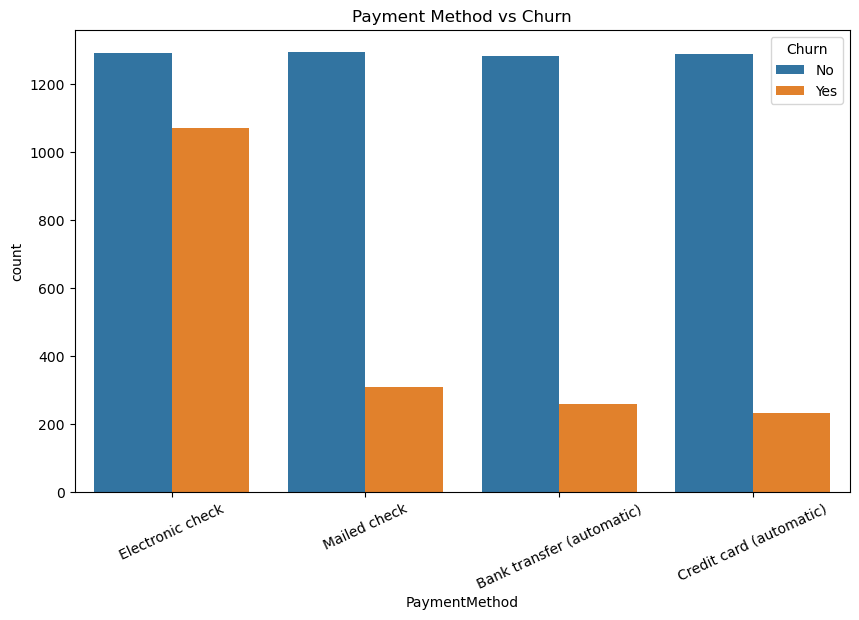

In [36]:
#Does Payment Method affect Customer Churn?
plt.figure(figsize=(10,6))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=25)

plt.title("Payment Method vs Churn")

plt.show()

In [37]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [ ]:
# #Business Insight
# Customers who pay using Electronic Check are much more likely to churn than customers using automatic payment methods.
# (There is a strong relationship between Electronic Check payment and higher churn.)


# #Business Recommendation
# Encourage customers using Electronic Check to switch to automatic payment methods by offering incentives such as discounts or cashback.


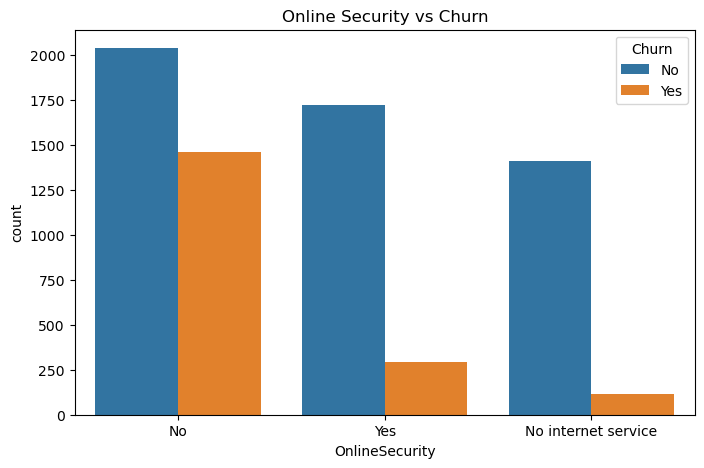

In [38]:
#Does Online Security affect Customer Churn?
plt.figure(figsize=(8,5))

sns.countplot(
    x="OnlineSecurity",
    hue="Churn",
    data=df
)

plt.title("Online Security vs Churn")
plt.show()

In [39]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


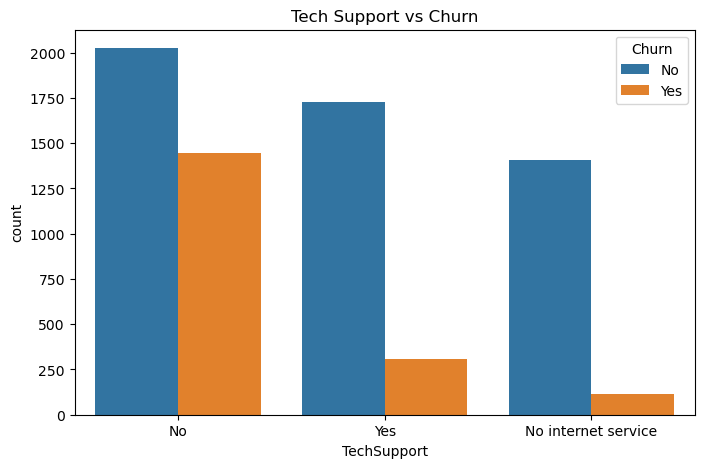

In [40]:
#Does Tech Support affect Customer Churn?
plt.figure(figsize=(8,5))

sns.countplot(
    x="TechSupport",
    hue="Churn",
    data=df
)

plt.title("Tech Support vs Churn")
plt.show()

In [41]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


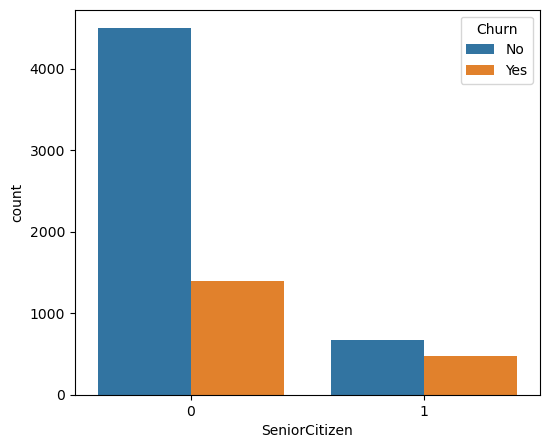

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [42]:
#
plt.figure(figsize=(6,5))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.show()

pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
)*100

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [44]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [45]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [46]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [47]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [ ]:
#Binary : gender , Partner , Dependents , PhoneService , PaperlessBilling
#Multi Category : MultipleLines , InternetService , OnlineSecurity , OnlineBackup , DeviceProtection , TechSupport , StreamingTV , StreamingMovies , Contract , PaymentMethod

X = pd.get_dummies(
    X,
    drop_first=True  #female=1-male
)

X.head

<bound method NDFrame.head of       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0                 0       1           29.85         29.85        False   
1                 0      34           56.95       1889.50         True   
2                 0       2           53.85        108.15         True   
3                 0      45           42.30       1840.75         True   
4                 0       2           70.70        151.65        False   
...             ...     ...             ...           ...          ...   
7038              0      24           84.80       1990.50         True   
7039              0      72          103.20       7362.90        False   
7040              0      11           29.60        346.45        False   
7041              1       4           74.40        306.60         True   
7042              0      66          105.65       6844.50         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            True         

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y 

)

print(X_train.shape)

print(X_test.shape)

(5625, 30)
(1407, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [ ]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

prob = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, prob)

print("ROC AUC:", roc)

Accuracy: 0.8038379530916845
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC AUC: 0.8356727976766699


In [61]:
# DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)


dt_model.fit(X_train, y_train)


y_pred_dt = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7782515991471215
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [63]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7867803837953091
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
# Random Forest does not always outperform simpler models. On this dataset, Logistic Regression generalized better,
# while the default Random Forest model did not achieve better recall or overall accuracy.
# Random Forest may require hyperparameter tuning to improve its performance.

In [64]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.194313
1,tenure,0.168529
2,MonthlyCharges,0.167972
10,InternetService_Fiber optic,0.038913
28,PaymentMethod_Electronic check,0.037898
25,Contract_Two year,0.031862
4,gender_Male,0.028939
13,OnlineSecurity_Yes,0.027288
26,PaperlessBilling_Yes,0.025595
5,Partner_Yes,0.023280


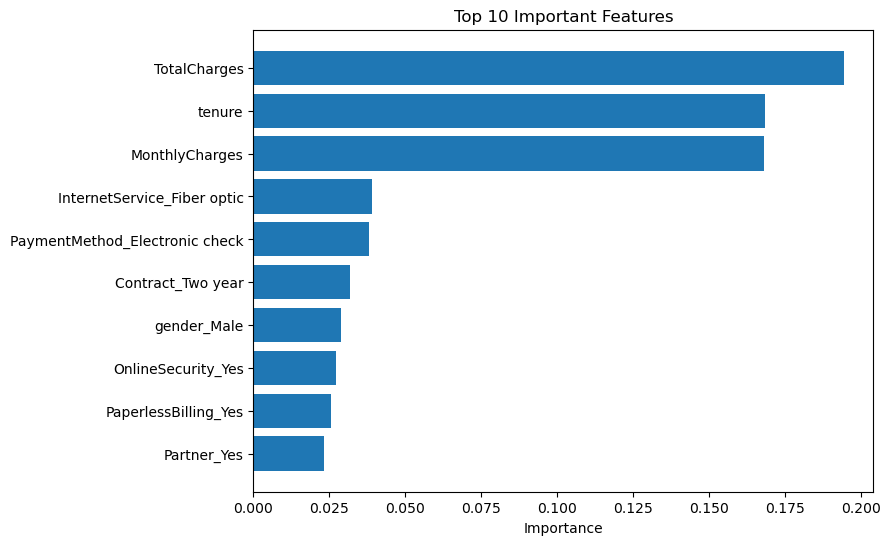

In [65]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [66]:
#ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


ann = Sequential()

# Input + Hidden Layer 1
ann.add(Dense(units=16, activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer 2
ann.add(Dense(units=8, activation='relu'))

# Output Layer
ann.add(Dense(units=1, activation='sigmoid'))


ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = ann.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


y_prob = ann.predict(X_test)

y_pred_ann = (y_prob > 0.5).astype(int)



from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_ann))

print(classification_report(y_test, y_pred_ann))

Epoch 1/50


C:\Users\Mina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6940 - loss: 0.5754 - val_accuracy: 0.7778 - val_loss: 0.4773
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7911 - loss: 0.4601 - val_accuracy: 0.7902 - val_loss: 0.4290
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4373 - val_accuracy: 0.7964 - val_loss: 0.4175
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4293 - val_accuracy: 0.7964 - val_loss: 0.4113
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8033 - loss: 0.4236 - val_accuracy: 0.7973 - val_loss: 0.4080
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8044 - loss: 0.4194 - val_accuracy: 0.8009 - val_loss: 0.4057
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8082 - loss: 0.4167 - val_accuracy: 0.8036 - val_loss: 0.4096
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8064 - loss: 0.4142 - val_accuracy: 0.7991 - val_

In [ ]:
# #Final Business Conclusion

# The objective of this project was to predict customer churn and identify the factors that influence customer retention.
# Exploratory Data Analysis showed that customers with month-to-month contracts, higher monthly charges, fiber optic internet service,
# electronic check payments, and shorter tenure were more likely to churn.

# Four machine learning models were evaluated: Logistic Regression, Decision Tree, Random Forest, and Artificial Neural Network (ANN).
# Among these models, Logistic Regression achieved the best overall performance with an accuracy of 80.38% and an ROC AUC of 0.836.
# Therefore, it was selected as the final model for predicting customer churn.

In [ ]:
# #Final Business Recommendations

# Focus on new customers, especially during the first 6–12 months.
# Encourage long-term contracts (One-year and Two-year plans).
# Review Fiber Optic service quality and pricing, as Fiber Optic users had higher churn rates.
# Reduce high monthly charges or provide discounts to high-paying customers.
# Encourage automatic payment methods instead of Electronic Check.
# Offer proactive customer support and online security services to customers at risk of churning.

In [69]:
import pandas as pd

df_feedback = pd.read_csv("telco_churn_with_all_feedback.csv")

df_feedback.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...


In [70]:
df_feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [71]:
df_feedback.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'PromptInput', 'CustomerFeedback'],
      dtype='object')

In [72]:
df_feedback.drop(columns=["PromptInput"], inplace=True)

In [73]:
df_feedback["CustomerFeedback"].isnull().sum()

np.int64(0)

In [74]:
for i in range(3):
    print(f"Review {i+1}")
    print(df_feedback["CustomerFeedback"][i])
    print("-"*100)

Review 1
I have been using the DSL internet service from this provider for the past month and so far, I am satisfied with the service. The connection has been reliable and the speed is sufficient for my needs. The monthly charges are reasonable at $29.85 and I appreciate the convenience of paying through electronic check. Overall, I have had a positive experience and would recommend this provider to others.
----------------------------------------------------------------------------------------------------
Review 2
I have been a customer with this company for over two and a half years now and I have been very satisfied with their service. The DSL internet has been reliable and the monthly charges are reasonable at $56.95. I prefer to pay by mailing in a check and have never had any issues with my payments. Overall, I have no complaints and would recommend this company to others looking for internet service.
-------------------------------------------------------------------------------

In [75]:
df_feedback["CustomerFeedback"].dtype

dtype('O')

In [ ]:
#cleaning
review = df_feedback.loc[0, "CustomerFeedback"]
print(review)

I have been using the DSL internet service from this provider for the past month and so far, I am satisfied with the service. The connection has been reliable and the speed is sufficient for my needs. The monthly charges are reasonable at $29.85 and I appreciate the convenience of paying through electronic check. Overall, I have had a positive experience and would recommend this provider to others.


In [77]:
#lower_case
review_lower = review.lower()
print(review_lower)

i have been using the dsl internet service from this provider for the past month and so far, i am satisfied with the service. the connection has been reliable and the speed is sufficient for my needs. the monthly charges are reasonable at $29.85 and i appreciate the convenience of paying through electronic check. overall, i have had a positive experience and would recommend this provider to others.


In [78]:
#Remove Punctuation
import string
review_no_punc = review_lower.translate(
    str.maketrans("", "", string.punctuation)
)

print(review_no_punc)

i have been using the dsl internet service from this provider for the past month and so far i am satisfied with the service the connection has been reliable and the speed is sufficient for my needs the monthly charges are reasonable at 2985 and i appreciate the convenience of paying through electronic check overall i have had a positive experience and would recommend this provider to others


In [ ]:
import re

review_no_num = re.sub(r'\d+', '', review_no_punc)

print(review_no_num)

i have been using the dsl internet service from this provider for the past month and so far i am satisfied with the service the connection has been reliable and the speed is sufficient for my needs the monthly charges are reasonable at  and i appreciate the convenience of paying through electronic check overall i have had a positive experience and would recommend this provider to others


In [80]:
#Tokenization
tokens = review_no_num.split()

print(tokens)

['i', 'have', 'been', 'using', 'the', 'dsl', 'internet', 'service', 'from', 'this', 'provider', 'for', 'the', 'past', 'month', 'and', 'so', 'far', 'i', 'am', 'satisfied', 'with', 'the', 'service', 'the', 'connection', 'has', 'been', 'reliable', 'and', 'the', 'speed', 'is', 'sufficient', 'for', 'my', 'needs', 'the', 'monthly', 'charges', 'are', 'reasonable', 'at', 'and', 'i', 'appreciate', 'the', 'convenience', 'of', 'paying', 'through', 'electronic', 'check', 'overall', 'i', 'have', 'had', 'a', 'positive', 'experience', 'and', 'would', 'recommend', 'this', 'provider', 'to', 'others']


In [81]:
#stop words
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mina\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [82]:
stop_words = set(stopwords.words("english"))

In [84]:
filtered_tokens = [
    word
    for word in tokens
    if word not in stop_words
]
print(filtered_tokens)

['using', 'dsl', 'internet', 'service', 'provider', 'past', 'month', 'far', 'satisfied', 'service', 'connection', 'reliable', 'speed', 'sufficient', 'needs', 'monthly', 'charges', 'reasonable', 'appreciate', 'convenience', 'paying', 'electronic', 'check', 'overall', 'positive', 'experience', 'would', 'recommend', 'provider', 'others']


In [85]:
#lemmatizer
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mina\AppData\Roaming\nltk_data...


In [86]:
lemmatized_tokens = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print(lemmatized_tokens)

#lemmatizer.lemmatize("using", pos="v")

['using', 'dsl', 'internet', 'service', 'provider', 'past', 'month', 'far', 'satisfied', 'service', 'connection', 'reliable', 'speed', 'sufficient', 'need', 'monthly', 'charge', 'reasonable', 'appreciate', 'convenience', 'paying', 'electronic', 'check', 'overall', 'positive', 'experience', 'would', 'recommend', 'provider', 'others']


In [ ]:
def clean_text(text):
    ...
    return cleaned_text

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)


df_feedback["Clean_Review"] = df_feedback["CustomerFeedback"].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mina\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mina\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [95]:
df_feedback[["CustomerFeedback", "Clean_Review"]].head()

,CustomerFeedback,Clean_Review
0,I have been using the DSL internet service fro...,using dsl internet service provider past month...
1,I have been a customer with this company for o...,customer company two half year satisfied servi...
2,I recently signed up for DSL internet service ...,recently signed dsl internet service provider ...
3,I have been a loyal customer with this company...,loyal customer company month satisfied service...
4,I recently switched to this fiber optic intern...,recently switched fiber optic internet service...


In [96]:
#Most Common Words
from collections import Counter

all_words = " ".join(df_feedback["Clean_Review"]).split()

word_freq = Counter(all_words)

word_freq.most_common(20)

[('service', 18162),
 ('internet', 9873),
 ('company', 7340),
 ('monthly', 7280),
 ('customer', 7033),
 ('charge', 6940),
 ('overall', 6896),
 ('provider', 6100),
 ('satisfied', 5833),
 ('payment', 5453),
 ('month', 4979),
 ('reasonable', 4927),
 ('issue', 4384),
 ('check', 3927),
 ('reliable', 3804),
 ('appreciate', 3321),
 ('would', 3200),
 ('convenient', 3145),
 ('fiber', 3128),
 ('optic', 3128)]

In [97]:
import pandas as pd

top_words = pd.DataFrame(
    word_freq.most_common(15),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,service,18162
1,internet,9873
2,company,7340
3,monthly,7280
4,customer,7033
5,charge,6940
6,overall,6896
7,provider,6100
8,satisfied,5833
9,payment,5453


In [99]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


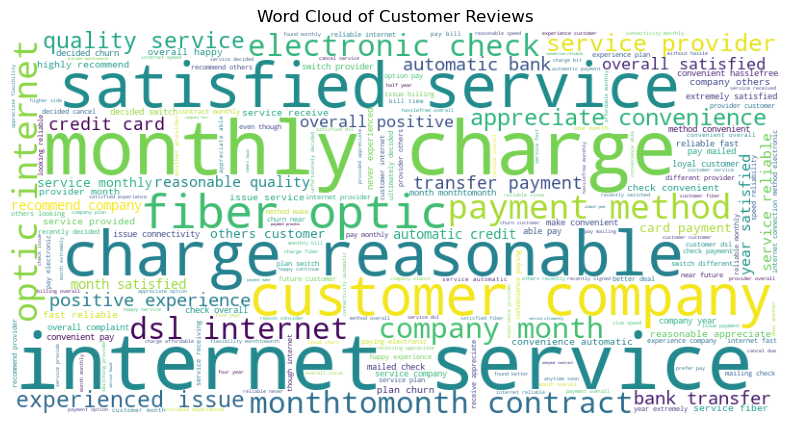

In [100]:
#Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(df_feedback["Clean_Review"]))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")
plt.show()

In [102]:
#Sentiment Analysis
!pip install textblob
import nltk
nltk.download('punkt')
from textblob import TextBlob

df_feedback["Sentiment"] = df_feedback["Clean_Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.8 MB/s  0:00:00


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mina\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [103]:
def sentiment_label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df_feedback["Sentiment_Label"] = df_feedback["Sentiment"].apply(sentiment_label)

In [104]:
df_feedback["Sentiment_Label"].value_counts()

Sentiment_Label
Positive    6468
Negative     550
Neutral       25
Name: count, dtype: int64

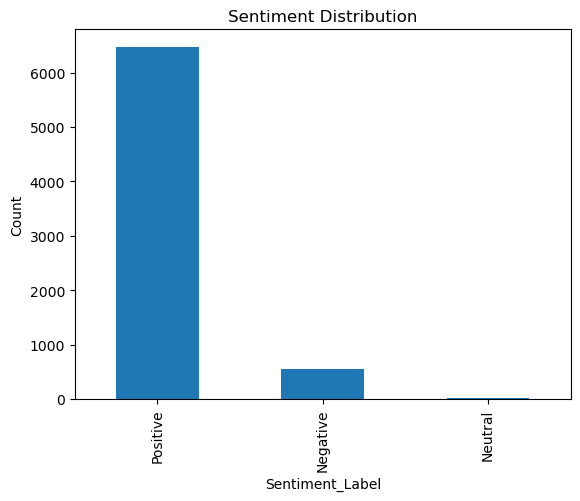

In [105]:
import matplotlib.pyplot as plt

df_feedback["Sentiment_Label"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.ylabel("Count")

plt.show()

In [ ]:
pd.crosstab(
    df_feedback["Sentiment_Label"],
    df_feedback["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Sentiment_Label,,
Negative,8.727273,91.272727
Neutral,64.000000,36.000000
Positive,79.004329,20.995671


In [107]:
#nlp model
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_text = tfidf.fit_transform(df_feedback["Clean_Review"])

In [108]:
y = df_feedback["Churn"]

In [109]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

In [111]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [112]:
y_pred = model.predict(X_test)

In [113]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))

1.0


In [ ]:
# Bert Model
!pip install transformers torch
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",   
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

In [ ]:
#check for the model
classifier(
    "The internet is very slow and customer support is terrible."
)

[{'label': 'NEGATIVE', 'score': 0.9997988343238831}]

In [ ]:
review = df_feedback.loc[0,"CustomerFeedback"]

classifier(review)

[{'label': 'POSITIVE', 'score': 0.9993283748626709}]

In [ ]:
results = [] 

for review in df_feedback["CustomerFeedback"].head(10):

    results.append(classifier(review)[0])

results

[{'label': 'POSITIVE', 'score': 0.9993283748626709},
 {'label': 'POSITIVE', 'score': 0.9972564578056335},
 {'label': 'NEGATIVE', 'score': 0.9996411800384521},
 {'label': 'POSITIVE', 'score': 0.9991415739059448},
 {'label': 'NEGATIVE', 'score': 0.999666690826416},
 {'label': 'NEGATIVE', 'score': 0.9995145797729492},
 {'label': 'POSITIVE', 'score': 0.9988452196121216},
 {'label': 'POSITIVE', 'score': 0.9954258799552917},
 {'label': 'NEGATIVE', 'score': 0.9994888305664062},
 {'label': 'POSITIVE', 'score': 0.9983465671539307}]

In [ ]:
#LLM
import google.generativeai as genai

genai.configure(api_key="---------------------------------------")

model = genai.GenerativeModel("gemini-flash-latest")

In [143]:
response = model.generate_content("Say hello in one sentence.")

print(response.text)

Hello, I hope you are having a wonderful day!


In [144]:
review = """
The internet is very slow and customer support never responds.
I am thinking about switching to another company.
"""

prompt = f"""
You are a telecom customer retention expert.

Analyze the following customer review.

Customer Review:
{review}

Return:
1. Sentiment (Positive / Neutral / Negative)
2. Churn Risk (Low / Medium / High)
3. Main Problems
4. Recommended Action for the company
"""

response = model.generate_content(prompt)

print(response.text)

Based on my analysis of the customer's review, here is the assessment and strategic recommendation from a customer retention perspective:

### 1. Sentiment
* **Negative** 
The customer is expressing active frustration with both core product performance (internet speed) and customer service, leading to a strong desire to leave.

### 2. Churn Risk
* **High** 
The customer has explicitly stated, *"I am thinking about switching to another company."* This is a clear red flag indicating they are in the active consideration phase of the churn funnel and likely exploring competitor offers. Immediate intervention is required.

### 3. Main Problems
* **Product Quality (Technical Issue):** Severely degraded internet speeds that do not meet expectations.
* **Customer Service Failure (Process Issue):** Complete lack of responsiveness from the support team, leaving the customer feeling ignored and helpless.

### 4. Recommended Action for the Company
To retain this customer, you must execute a swift,

In [146]:
!pip install vaderSentiment

In [ ]:
# Vader
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_result(review):

    score = analyzer.polarity_scores(review)["compound"]

    if score >= 0.05:
        sentiment = "Positive"
    elif score <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    return sentiment, score

In [ ]:
#Bert
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [149]:
def bert_result(review):

    result = classifier(review)[0]

    return result["label"], result["score"]

In [ ]:
# gemini
def llm_analysis(review):

    prompt = f"""

You are a telecom customer retention expert.

Analyze this customer review.

Customer Review:
{review}

Return ONLY:

Customer Sentiment:
Churn Risk:
Main Problems:
Business Recommendation:

"""

    response = model.generate_content(prompt)

    return response.text

In [152]:
#AI Agent
def customer_ai_agent(review):

    vader_sentiment, vader_score = vader_result(review)

    bert_sentiment, bert_score = bert_result(review)

    llm = llm_analysis(review)

    print("="*60)

    print("🤖 AI CUSTOMER RETENTION AGENT")

    print("="*60)

    print("\nCustomer Review:\n")
    print(review)

    print("\n------------------------------")

    print(f"VADER Sentiment : {vader_sentiment}")
    print(f"VADER Score     : {vader_score:.3f}")

    print()

    print(f"BERT Sentiment  : {bert_sentiment}")
    print(f"BERT Confidence : {bert_score:.3f}")

    print("\n------------------------------")

    print(llm)

    print("="*60)

In [154]:
customer_ai_agent(input("Enter Customer Review: "))

Enter Customer Review:  I'm not good because, the internet is slow


🤖 AI CUSTOMER RETENTION AGENT

Customer Review:

I'm not good because, the internet is slow

------------------------------
VADER Sentiment : Negative
VADER Score     : -0.341

BERT Sentiment  : NEGATIVE
BERT Confidence : 1.000

------------------------------
Customer Sentiment: Negative
Churn Risk: Medium-High
Main Problems: Slow internet speed / poor connection quality
Business Recommendation: Proactively contact the customer to run technical diagnostics on their line, resolve the speed bottleneck, and offer a temporary service credit or complimentary speed upgrade as a goodwill gesture to prevent churn.
